# LSTM Autoencoder — S&P 500 Anomaly Detection

## 1. Project Overview and Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow:', tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow: 2.21.0


## 2. Load and Inspect the S&P 500 Index Data

In [2]:
df = pd.read_csv('S&P_500_Index_Data.csv')
df.columns = df.columns.str.strip()
df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)
df = df.sort_values('date').reset_index(drop=True)
print(df.shape)
df.head()

(8192, 2)


C:\Users\akrou\AppData\Local\Temp\ipykernel_28976\1879226030.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)
C:\Users\akrou\AppData\Local\Temp\ipykernel_28976\1879226030.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True)


,date,close
0,1986-01-02,209.59
1,1986-01-03,210.88
2,1986-01-06,210.65
3,1986-01-07,213.80
4,1986-01-08,207.97


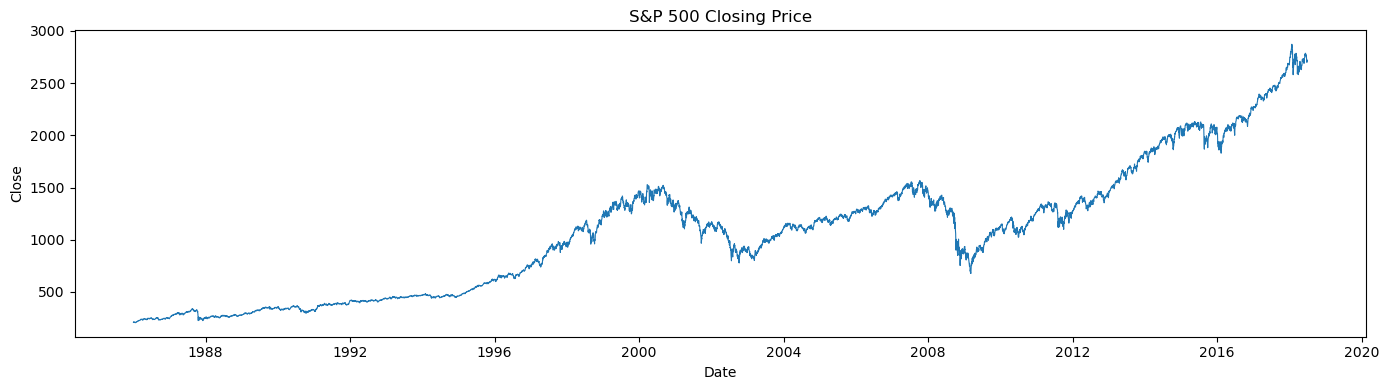

count    8192.000000
mean     1070.897411
std       616.714534
min       203.490000
25%       458.632500
50%      1106.435000
75%      1388.132500
max      2872.870000
Name: close, dtype: float64


In [3]:
plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['close'], linewidth=0.8)
plt.title('S&P 500 Closing Price')
plt.xlabel('Date'); plt.ylabel('Close')
plt.tight_layout(); plt.show()
print(df['close'].describe())

## 3. Data Preprocessing

In [4]:
SEQ_LEN = 30

scaler = MinMaxScaler()
close_scaled = scaler.fit_transform(df[['close']]).flatten()

def create_sequences(data, seq_len):
    return np.array([data[i:i+seq_len] for i in range(len(data)-seq_len+1)])[..., np.newaxis]

X_all     = create_sequences(close_scaled, SEQ_LEN)
dates_seq = df['date'].values[SEQ_LEN - 1:]
print('All sequences shape:', X_all.shape)

All sequences shape: (8163, 30, 1)


## 4. Create Training and Test Splits

In [5]:
split_date = pd.Timestamp('2008-01-01')
train_mask = pd.to_datetime(dates_seq) < split_date

X_train    = X_all[train_mask]
X_test     = X_all[~train_mask]
dates_test = dates_seq[~train_mask]

print('Train:', X_train.shape, '  Test:', X_test.shape)

Train: (5520, 30, 1)   Test: (2643, 30, 1)


## 5. Build an LSTM Autoencoder

In [6]:
def build_autoencoder(seq_len, n_features=1):
    inp = Input(shape=(seq_len, n_features))
    x   = LSTM(64, activation='tanh', return_sequences=False)(inp)
    x   = RepeatVector(seq_len)(x)
    x   = LSTM(64, activation='tanh', return_sequences=True)(x)
    out = TimeDistributed(Dense(n_features))(x)
    m   = Model(inp, out)
    m.compile(optimizer='adam', loss='mae')
    return m

model = build_autoencoder(SEQ_LEN)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Autoencoder

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0285 - val_loss: 0.0224
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0092 - val_loss: 0.0117
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0071 - val_loss: 0.0076
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0071 - val_loss: 0.0078
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0053 - val_loss: 0.0094
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0052 - val_loss: 0.0112
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0052 - val_loss: 0.0122
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0052 - val_loss: 0.0116


## 7. Plot Metrics and Evaluate the Model

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]

axes[0].plot(train_loss, label="Train MAE",      color="steelblue")
axes[0].plot(val_loss,   label="Validation MAE", color="darkorange", linestyle="--")
axes[0].set_title("Train vs Validation Loss (MAE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

train_delta = [train_loss[0] - v for v in train_loss]
val_delta   = [val_loss[0]   - v for v in val_loss]
axes[1].plot(train_delta, label="Train improvement",      color="steelblue")
axes[1].plot(val_delta,   label="Validation improvement", color="darkorange", linestyle="--")
axes[1].set_title("Cumulative MAE Improvement")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE Reduction from Epoch 0")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best train MAE : {min(train_loss):.6f}")
print(f"Best val MAE   : {min(val_loss):.6f}")
print(f"Epochs trained : {len(train_loss)}")

In [ ]:
X_pred_all   = model.predict(X_all, batch_size=256)
mae_all      = np.mean(np.abs(X_pred_all - X_all), axis=(1, 2))

train_errors = mae_all[train_mask]
threshold    = np.mean(train_errors) + 3 * np.std(train_errors)
print(f'Threshold (mean+3sigma): {threshold:.6f}')

plt.figure(figsize=(10, 4))
plt.hist(train_errors, bins=60, alpha=0.7, label='Train errors')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold={threshold:.4f}')
plt.title('Reconstruction Error Distribution (Training Set)')
plt.xlabel('MAE'); plt.ylabel('Count')
plt.legend(); plt.tight_layout(); plt.show()

## 8. Detect Anomalies in the S&P 500 Index Data

In [ ]:
anomaly_flags = mae_all > threshold
print(f'Sequences : {len(mae_all)}')
print(f'Anomalies : {anomaly_flags.sum()} ({100*anomaly_flags.mean():.1f}%)')

In [ ]:
price_seq = scaler.inverse_transform(close_scaled[SEQ_LEN-1:].reshape(-1,1)).flatten()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(dates_seq, price_seq, linewidth=0.8, color='steelblue', label='S&P 500')
axes[0].scatter(dates_seq[anomaly_flags], price_seq[anomaly_flags],
                color='red', s=8, zorder=3, label='Anomaly')
axes[0].set_title('S&P 500 Closing Price with Detected Anomalies')
axes[0].set_ylabel('Close'); axes[0].legend()

axes[1].plot(dates_seq, mae_all, linewidth=0.6, color='darkorange', label='Recon. Error')
axes[1].axhline(threshold, color='red', linestyle='--', label=f'Threshold={threshold:.4f}')
axes[1].set_title('Per-Window Reconstruction Error (MAE)')
axes[1].set_ylabel('MAE'); axes[1].set_xlabel('Date'); axes[1].legend()

axes[1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

In [ ]:
anomaly_df = pd.DataFrame({'date': dates_seq[anomaly_flags], 'mae': mae_all[anomaly_flags]})
anomaly_df = anomaly_df.sort_values('date').reset_index(drop=True)
print('Top-20 anomaly dates by reconstruction error:')
anomaly_df.nlargest(20, 'mae')